Daftar Gambar:
['Foto_Ideal.jpeg', 'Foto_Cluttered.jpeg', 'Foto_MotionBlur.jpeg', 'Foto_LongDistance.jpeg', 'Foto_LowLight.jpeg']


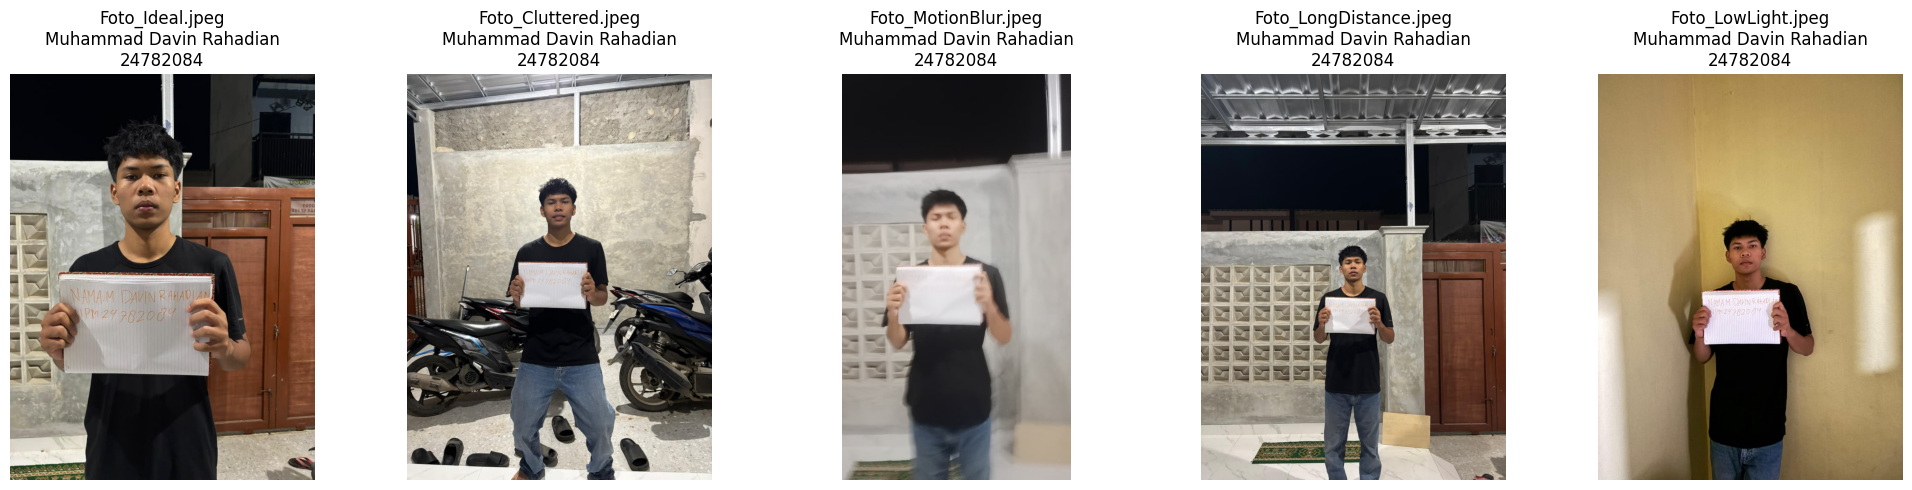

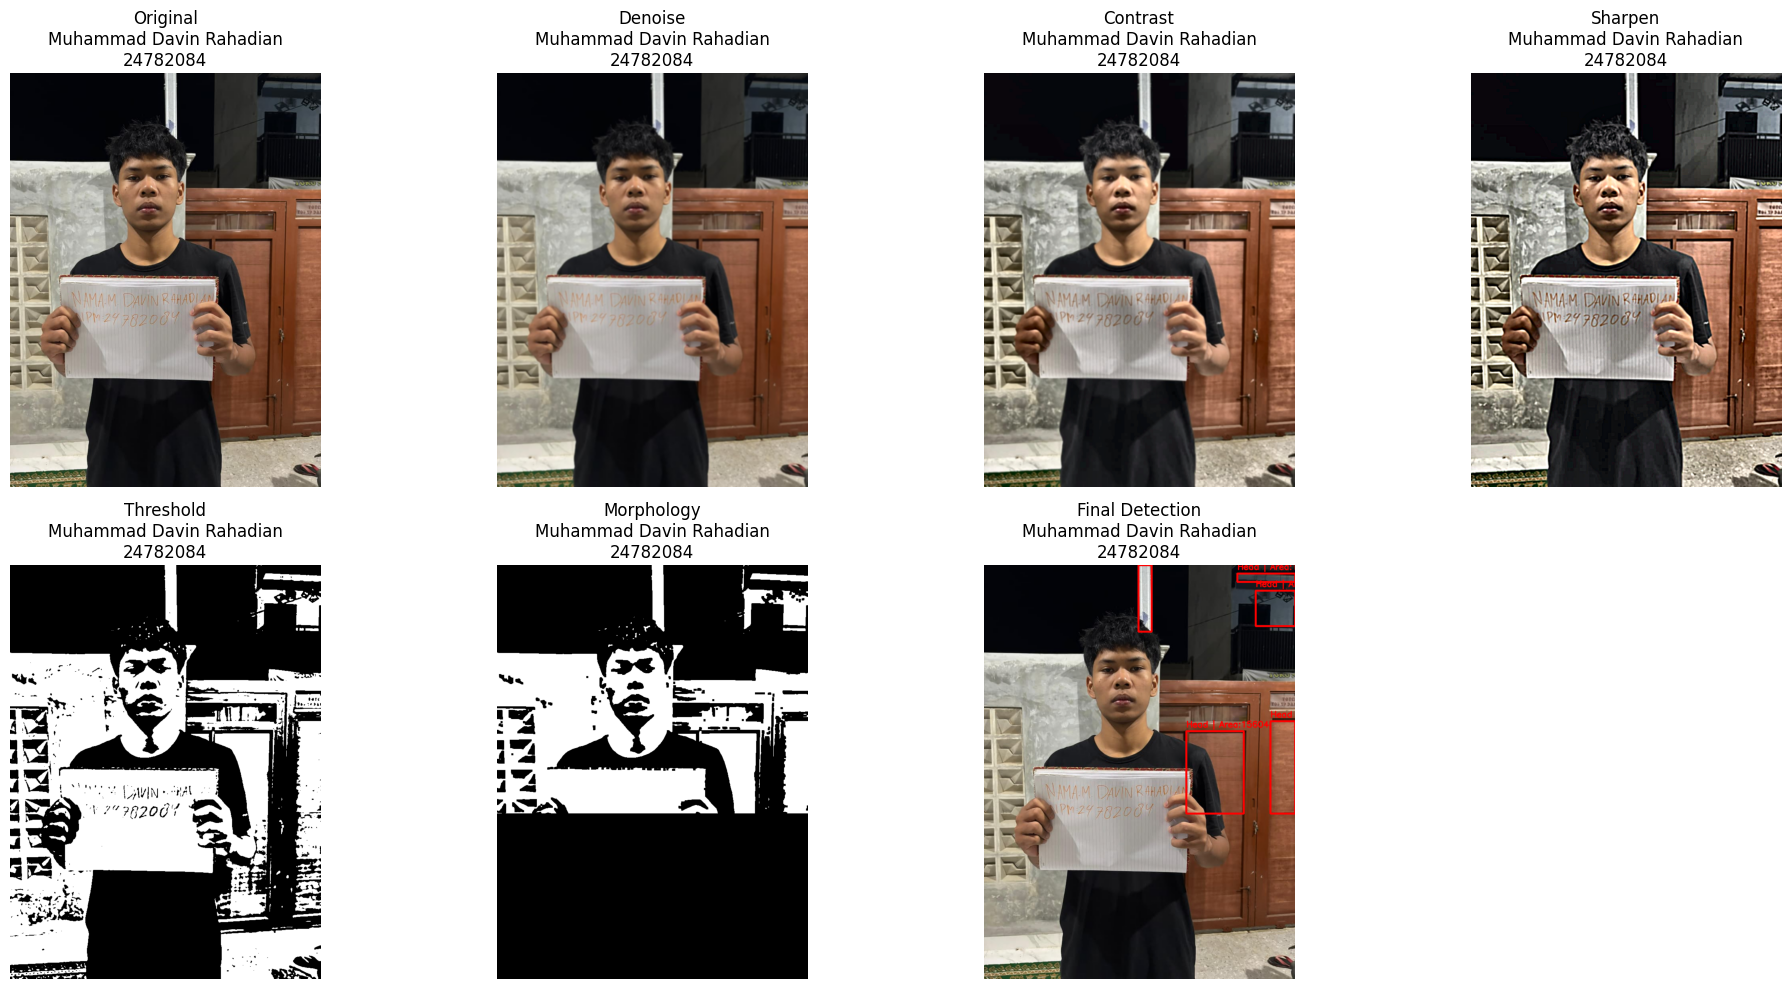

Status Detection:
Head Detected

Detected Features:
[{'Area': 15604.0, 'Mean Intensity': np.float64(110.84702093397746)}, {'Area': 13090.5, 'Mean Intensity': np.float64(142.15273915461623)}, {'Area': 4658.5, 'Mean Intensity': np.float64(88.85030076041312)}, {'Area': 1984.5, 'Mean Intensity': np.float64(118.87881773399015)}, {'Area': 4231.0, 'Mean Intensity': np.float64(172.80293957539467)}]


In [30]:
# ====================================================
# LAB SESSION 9 - COMPUTER VISION
# Pipeline Error Analysis & Robustness
#
# Nama : Muhammad Davin Rahadian
# NPM  : 24782084
# ====================================================

# ====================================================
# IMPORT LIBRARY
# ====================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====================================================
# PATH DATASET
# ====================================================

dataset_path = "/content/lab9"

# ====================================================
# CEK DATASET
# ====================================================

image_files = [
    f for f in os.listdir(dataset_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Daftar Gambar:")
print(image_files)

# ====================================================
# PREVIEW DATASET
# ====================================================

fig, axes = plt.subplots(
    1,
    len(image_files),
    figsize=(20,5)
)

if len(image_files) == 1:
    axes = [axes]

for i, file in enumerate(image_files):

    path = os.path.join(dataset_path, file)

    img = cv2.imread(path)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(img_rgb)

    axes[i].set_title(
        f"{file}\n"
        "Muhammad Davin Rahadian\n"
        "24782084"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ====================================================
# PIPELINE FUNCTION
# ====================================================

def process_pipeline(
    image_path,
    sigma=1.5,
    clip_limit=2.0,
    amount=1.5,
    min_area=1000,
    max_area=50000,
    intensity_threshold=80
):

    # =================================================
    # LOAD IMAGE
    # =================================================

    image = cv2.imread(image_path)

    original = image.copy()

    # =================================================
    # LOW-LEVEL PROCESSING
    # =================================================

    # Gaussian Denoising
    denoise = cv2.GaussianBlur(
        image,
        (5,5),
        sigma
    )

    # CLAHE Contrast Enhancement
    lab = cv2.cvtColor(
        denoise,
        cv2.COLOR_BGR2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    limg = cv2.merge((cl,a,b))

    contrast = cv2.cvtColor(
        limg,
        cv2.COLOR_LAB2BGR
    )

    # Sharpening (Unsharp Mask)
    blur = cv2.GaussianBlur(
        contrast,
        (0,0),
        3
    )

    sharpen = cv2.addWeighted(
        contrast,
        1 + amount,
        blur,
        -amount,
        0
    )

    # =================================================
    # MID-LEVEL PROCESSING
    # =================================================

    gray = cv2.cvtColor(
        sharpen,
        cv2.COLOR_BGR2GRAY
    )

    # Otsu Threshold
    _, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Morphological Operation
    kernel = np.ones((5,5), np.uint8)

    morph = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel
    )

    # =================================================
    # ROI MASKING
    # Fokus area atas gambar
    # =================================================

    height, width = morph.shape

    roi_mask = np.zeros_like(morph)

    roi_mask[0:int(height * 0.6), :] = 255

    morph = cv2.bitwise_and(
        morph,
        roi_mask
    )

    # =================================================
    # HIGH-LEVEL PROCESSING
    # =================================================

    contours, _ = cv2.findContours(
        morph,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    result = original.copy()

    detection = "No Head Detected"

    detected_features = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        # Filter area
        if area < min_area or area > max_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        roi = gray[y:y+h, x:x+w]

        mean_intensity = np.mean(roi)

        if mean_intensity > intensity_threshold:

            detection = "Head Detected"

            # Bounding Box merah
            cv2.rectangle(
                result,
                (x,y),
                (x+w,y+h),
                (0,0,255),
                3
            )

            # Label
            label = f"Head | Area:{int(area)}"

            cv2.putText(
                result,
                label,
                (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0,0,255),
                2
            )

            detected_features.append({
                "Area": area,
                "Mean Intensity": mean_intensity
            })

    # =================================================
    # RETURN OUTPUT
    # =================================================

    return {
        "original": original,
        "denoise": denoise,
        "contrast": contrast,
        "sharpen": sharpen,
        "threshold": thresh,
        "morph": morph,
        "result": result,
        "detection": detection,
        "features": detected_features
    }

# ====================================================
# TEST FOTO IDEAL
# ====================================================

test_image = "/content/lab9/Foto_Ideal.jpeg"

output = process_pipeline(test_image)

# ====================================================
# VISUALISASI PIPELINE
# ====================================================

titles = [
    "Original",
    "Denoise",
    "Contrast",
    "Sharpen",
    "Threshold",
    "Morphology",
    "Final Detection"
]

images = [
    cv2.cvtColor(output["original"], cv2.COLOR_BGR2RGB),
    cv2.cvtColor(output["denoise"], cv2.COLOR_BGR2RGB),
    cv2.cvtColor(output["contrast"], cv2.COLOR_BGR2RGB),
    cv2.cvtColor(output["sharpen"], cv2.COLOR_BGR2RGB),
    output["threshold"],
    output["morph"],
    cv2.cvtColor(output["result"], cv2.COLOR_BGR2RGB)
]

plt.figure(figsize=(20,10))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(
        f"{titles[i]}\n"
        "Muhammad Davin Rahadian\n"
        "24782084"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ====================================================
# STATUS DETEKSI
# ====================================================

print("Status Detection:")
print(output["detection"])

print("\nDetected Features:")
print(output["features"])

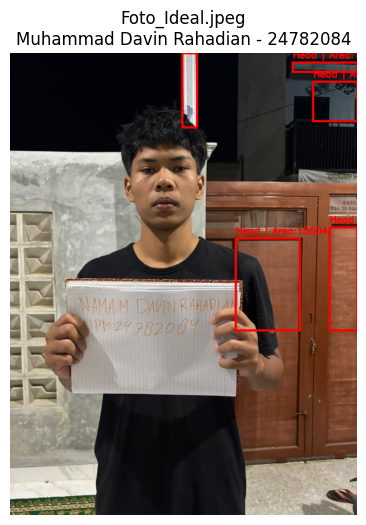

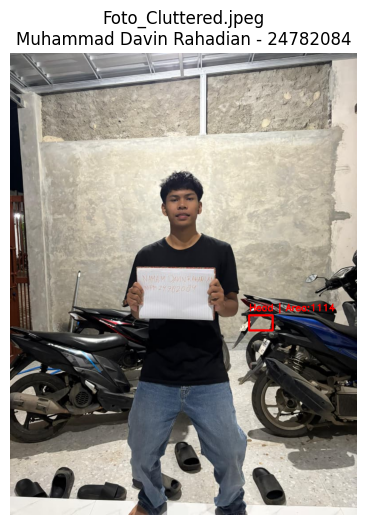

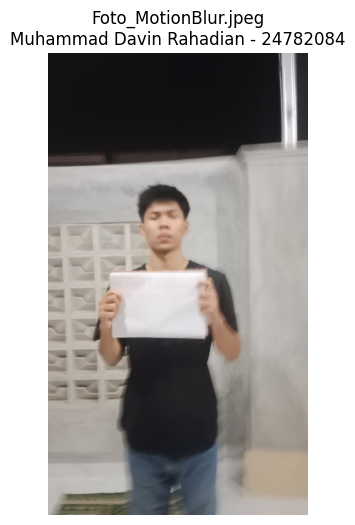

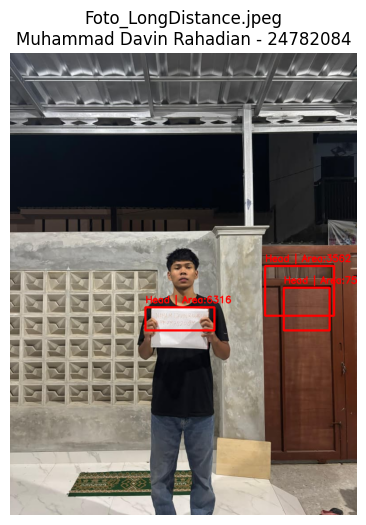

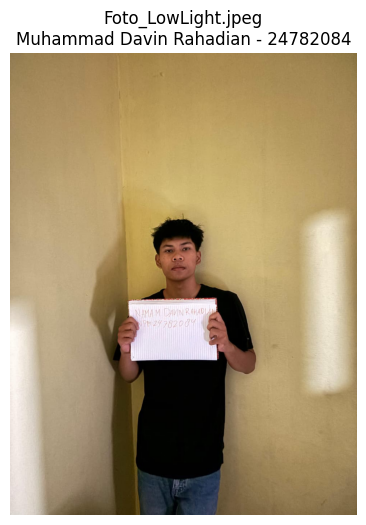

                  ID Foto     Prediksi Awal  \
0         Foto_Ideal.jpeg     Head Detected   
1     Foto_Cluttered.jpeg     Head Detected   
2    Foto_MotionBlur.jpeg  No Head Detected   
3  Foto_LongDistance.jpeg     Head Detected   
4      Foto_LowLight.jpeg  No Head Detected   

                       Diagnosis Kegagalan       Tahap yang Gagal  
0                  Deteksi berjalan normal              Tidak Ada  
1   Background ramai memicu false positive  High-Level Processing  
2  Objek blur sehingga contour tidak jelas  Low-Level & Mid-Level  
3              Ukuran kepala terlalu kecil  High-Level Processing  
4      Noise tinggi dan pencahayaan rendah   Low-Level Processing  


In [31]:
# ====================================================
# PIPELINE STRESS TEST
# Muhammad Davin Rahadian - 24782084
# ====================================================

results = []

for file in image_files:

    image_path = os.path.join(dataset_path, file)

    output = process_pipeline(image_path)

    # =================================================
    # TAMPILKAN HASIL DETEKSI
    # =================================================

    plt.figure(figsize=(6,6))

    plt.imshow(
        cv2.cvtColor(
            output["result"],
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"{file}\n"
        "Muhammad Davin Rahadian - 24782084"
    )

    plt.axis("off")

    plt.show()

    # =================================================
    # ANALISIS ERROR PIPELINE
    # =================================================

    if "Ideal" in file:

        diagnosis = "Deteksi berjalan normal"
        failed_stage = "Tidak Ada"

    elif "LowLight" in file:

        diagnosis = "Noise tinggi dan pencahayaan rendah"
        failed_stage = "Low-Level Processing"

    elif "MotionBlur" in file:

        diagnosis = "Objek blur sehingga contour tidak jelas"
        failed_stage = "Low-Level & Mid-Level"

    elif "LongDistance" in file:

        diagnosis = "Ukuran kepala terlalu kecil"
        failed_stage = "High-Level Processing"

    elif "Cluttered" in file:

        diagnosis = "Background ramai memicu false positive"
        failed_stage = "High-Level Processing"

    else:

        diagnosis = "-"
        failed_stage = "-"

    results.append({
        "ID Foto": file,
        "Prediksi Awal": output["detection"],
        "Diagnosis Kegagalan": diagnosis,
        "Tahap yang Gagal": failed_stage
    })

# ====================================================
# TABEL HASIL
# ====================================================

df_results = pd.DataFrame(results)

print(df_results)

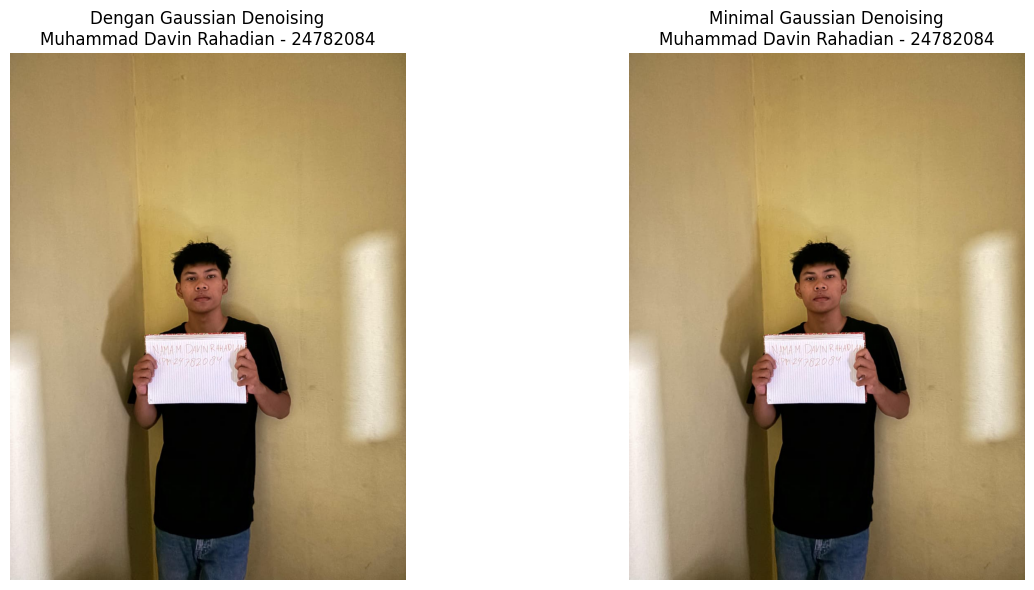

=== DENGAN DENOISING ===
No Head Detected
[]

=== MINIMAL DENOISING ===
No Head Detected
[]


In [32]:
# ============================================================
# MANUAL INTERVENTION - LOW LIGHT
# Muhammad Davin Rahadian - 24782084
# ============================================================

lowlight_path = "/content/lab9/Foto_LowLight.jpeg"

# ============================================================
# DENGAN DENOISING NORMAL
# ============================================================

with_denoise = process_pipeline(
    lowlight_path,
    sigma=1.5
)

# ============================================================
# DENOISING DIKURANGI
# ============================================================

without_denoise = process_pipeline(
    lowlight_path,
    sigma=0.5
)

# ============================================================
# VISUALISASI HASIL
# ============================================================

plt.figure(figsize=(14,6))

# Dengan denoising
plt.subplot(1,2,1)

plt.imshow(
    cv2.cvtColor(
        with_denoise["result"],
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Dengan Gaussian Denoising\n"
    "Muhammad Davin Rahadian - 24782084"
)

plt.axis("off")

# Denoising dikurangi
plt.subplot(1,2,2)

plt.imshow(
    cv2.cvtColor(
        without_denoise["result"],
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Minimal Gaussian Denoising\n"
    "Muhammad Davin Rahadian - 24782084"
)

plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# STATUS DETEKSI
# ============================================================

print("=== DENGAN DENOISING ===")
print(with_denoise["detection"])
print(with_denoise["features"])

print("\n=== MINIMAL DENOISING ===")
print(without_denoise["detection"])
print(without_denoise["features"])

In [33]:
analysis_lowlight = """
ANALISIS MANUAL INTERVENTION - LOW LIGHT

Berdasarkan hasil eksperimen, baik penggunaan Gaussian
Denoising maupun minimal denoising masih belum mampu
mendeteksi kepala pada kondisi low light.

Hal ini terjadi karena pencahayaan yang terlalu rendah
menyebabkan detail objek sulit dipisahkan dari background
saat proses thresholding dan contour detection.

Gaussian filter membantu mengurangi noise, namun pada
kondisi minim cahaya yang ekstrem, informasi penting pada
objek juga ikut berkurang sehingga proses klasifikasi gagal.

Eksperimen ini menunjukkan bahwa kualitas pencahayaan
sangat mempengaruhi performa pipeline computer vision.
"""

print(analysis_lowlight)


ANALISIS MANUAL INTERVENTION - LOW LIGHT

Berdasarkan hasil eksperimen, baik penggunaan Gaussian
Denoising maupun minimal denoising masih belum mampu
mendeteksi kepala pada kondisi low light.

Hal ini terjadi karena pencahayaan yang terlalu rendah
menyebabkan detail objek sulit dipisahkan dari background
saat proses thresholding dan contour detection.

Gaussian filter membantu mengurangi noise, namun pada
kondisi minim cahaya yang ekstrem, informasi penting pada
objek juga ikut berkurang sehingga proses klasifikasi gagal.

Eksperimen ini menunjukkan bahwa kualitas pencahayaan
sangat mempengaruhi performa pipeline computer vision.



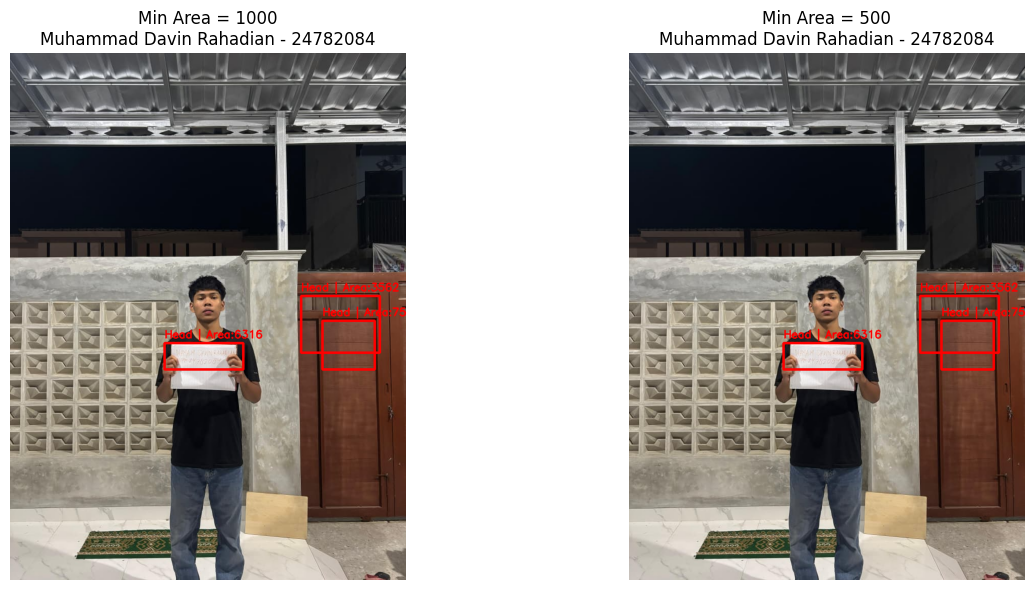

=== PARAMETER NORMAL ===
Head Detected
[{'Area': 6316.5, 'Mean Intensity': np.float64(176.63970223325063)}, {'Area': 7536.5, 'Mean Intensity': np.float64(133.0274069579288)}, {'Area': 3562.5, 'Mean Intensity': np.float64(108.11912442396313)}]

=== MIN_AREA DIPERKECIL ===
Head Detected
[{'Area': 6316.5, 'Mean Intensity': np.float64(176.63970223325063)}, {'Area': 7536.5, 'Mean Intensity': np.float64(133.0274069579288)}, {'Area': 3562.5, 'Mean Intensity': np.float64(108.11912442396313)}]


In [34]:
# ============================================================
# ANALISIS SENSITIVITAS FITUR
# Muhammad Davin Rahadian - 24782084
# ============================================================

longdistance_path = "/content/lab9/Foto_LongDistance.jpeg"

# ============================================================
# EKSPERIMEN 1
# PARAMETER NORMAL
# ============================================================

normal_detection = process_pipeline(
    longdistance_path,
    min_area=1000
)

# ============================================================
# EKSPERIMEN 2
# MIN_AREA DIPERKECIL 50%
# ============================================================

sensitive_detection = process_pipeline(
    longdistance_path,
    min_area=500
)

# ============================================================
# VISUALISASI PERBANDINGAN
# ============================================================

plt.figure(figsize=(14,6))

# ------------------------------------------------------------
# Parameter Normal
# ------------------------------------------------------------

plt.subplot(1,2,1)

plt.imshow(
    cv2.cvtColor(
        normal_detection["result"],
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Min Area = 1000\n"
    "Muhammad Davin Rahadian - 24782084"
)

plt.axis("off")

# ------------------------------------------------------------
# Min Area Diperkecil
# ------------------------------------------------------------

plt.subplot(1,2,2)

plt.imshow(
    cv2.cvtColor(
        sensitive_detection["result"],
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Min Area = 500\n"
    "Muhammad Davin Rahadian - 24782084"
)

plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# STATUS DETEKSI
# ============================================================

print("=== PARAMETER NORMAL ===")
print(normal_detection["detection"])
print(normal_detection["features"])

print("\n=== MIN_AREA DIPERKECIL ===")
print(sensitive_detection["detection"])
print(sensitive_detection["features"])

In [35]:
analysis_sensitivity = """
ANALISIS SENSITIVITAS FITUR

Berdasarkan hasil eksperimen, sistem tetap berhasil
mendeteksi kepala meskipun parameter min_area
diperkecil hingga 50%.

Perubahan parameter tidak memberikan perubahan
signifikan terhadap hasil deteksi karena ukuran
objek kepala masih cukup besar untuk memenuhi
threshold area.

Selain itu, tidak muncul false positive tambahan
pada background sehingga sistem masih cukup stabil.

Eksperimen ini menunjukkan bahwa parameter area
minimum mempengaruhi sensitivitas sistem.
Semakin kecil nilai min_area, sistem menjadi lebih
sensitif terhadap objek kecil, tetapi risiko false
positive juga dapat meningkat.
"""

print(analysis_sensitivity)


ANALISIS SENSITIVITAS FITUR

Berdasarkan hasil eksperimen, sistem tetap berhasil
mendeteksi kepala meskipun parameter min_area
diperkecil hingga 50%.

Perubahan parameter tidak memberikan perubahan
signifikan terhadap hasil deteksi karena ukuran
objek kepala masih cukup besar untuk memenuhi
threshold area.

Selain itu, tidak muncul false positive tambahan
pada background sehingga sistem masih cukup stabil.

Eksperimen ini menunjukkan bahwa parameter area
minimum mempengaruhi sensitivitas sistem.
Semakin kecil nilai min_area, sistem menjadi lebih
sensitif terhadap objek kecil, tetapi risiko false
positive juga dapat meningkat.



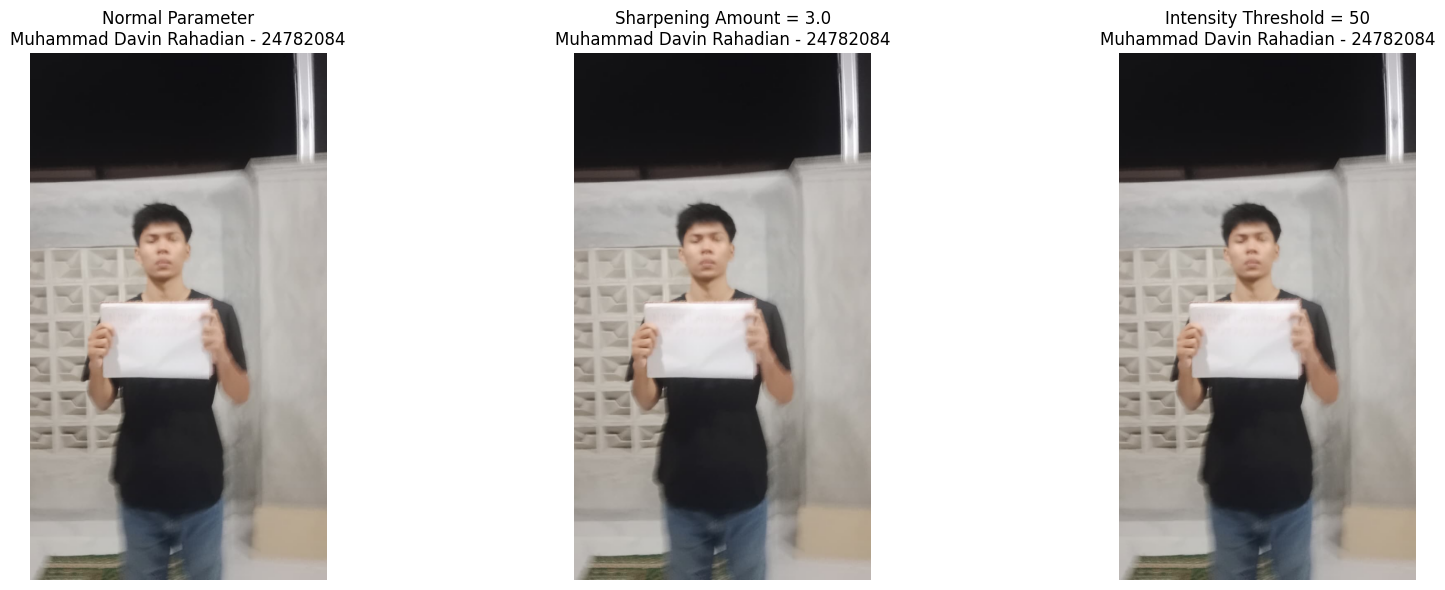

=== PARAMETER NORMAL ===
No Head Detected
[]

=== SHARPENING DITINGKATKAN ===
No Head Detected
[]

=== THRESHOLD DITURUNKAN ===
No Head Detected
[]


In [36]:
# ============================================================
# DIAGNOSIS: LOW-LEVEL VS HIGH-LEVEL
# Muhammad Davin Rahadian - 24782084
# ============================================================

blur_path = "/content/lab9/Foto_MotionBlur.jpeg"

# ============================================================
# EKSPERIMEN 1
# PARAMETER NORMAL
# ============================================================

normal_blur = process_pipeline(
    blur_path,
    amount=1.5,
    intensity_threshold=80
)

# ============================================================
# EKSPERIMEN 2
# MENINGKATKAN SHARPENING
# ============================================================

sharp_blur = process_pipeline(
    blur_path,
    amount=3.0,
    intensity_threshold=80
)

# ============================================================
# EKSPERIMEN 3
# MENURUNKAN THRESHOLD INTENSITAS
# ============================================================

threshold_blur = process_pipeline(
    blur_path,
    amount=1.5,
    intensity_threshold=50
)

# ============================================================
# VISUALISASI HASIL
# ============================================================

plt.figure(figsize=(18,6))

# ------------------------------------------------------------
# Parameter Normal
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    cv2.cvtColor(
        normal_blur["result"],
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Normal Parameter\n"
    "Muhammad Davin Rahadian - 24782084"
)

plt.axis("off")

# ------------------------------------------------------------
# Sharpening Ditingkatkan
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    cv2.cvtColor(
        sharp_blur["result"],
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Sharpening Amount = 3.0\n"
    "Muhammad Davin Rahadian - 24782084"
)

plt.axis("off")

# ------------------------------------------------------------
# Threshold Diturunkan
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    cv2.cvtColor(
        threshold_blur["result"],
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Intensity Threshold = 50\n"
    "Muhammad Davin Rahadian - 24782084"
)

plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# STATUS DETEKSI
# ============================================================

print("=== PARAMETER NORMAL ===")
print(normal_blur["detection"])
print(normal_blur["features"])

print("\n=== SHARPENING DITINGKATKAN ===")
print(sharp_blur["detection"])
print(sharp_blur["features"])

print("\n=== THRESHOLD DITURUNKAN ===")
print(threshold_blur["detection"])
print(threshold_blur["features"])

In [37]:
analysis_blur = """
ANALISIS LOW-LEVEL VS HIGH-LEVEL

Berdasarkan hasil eksperimen, peningkatan sharpening
(Unsharp Mask) maupun penurunan intensity threshold
masih belum mampu mendeteksi kepala pada gambar blur.

Hal ini menunjukkan bahwa motion blur menyebabkan
hilangnya detail penting dan membuat contour objek
menjadi tidak jelas.

Meningkatkan sharpening hanya mempertegas noise dan
tepi blur, tetapi tidak dapat mengembalikan informasi
visual yang sudah hilang akibat gerakan.

Sementara itu, menurunkan threshold intensitas tidak
memberikan hasil signifikan karena bentuk objek masih
sulit dipisahkan dari background.

Dari eksperimen ini dapat disimpulkan bahwa memperbaiki
kualitas gambar lebih penting dibanding hanya
melonggarkan logika klasifikasi pada kasus blur berat.
"""

print(analysis_blur)


ANALISIS LOW-LEVEL VS HIGH-LEVEL

Berdasarkan hasil eksperimen, peningkatan sharpening
(Unsharp Mask) maupun penurunan intensity threshold
masih belum mampu mendeteksi kepala pada gambar blur.

Hal ini menunjukkan bahwa motion blur menyebabkan
hilangnya detail penting dan membuat contour objek
menjadi tidak jelas.

Meningkatkan sharpening hanya mempertegas noise dan
tepi blur, tetapi tidak dapat mengembalikan informasi
visual yang sudah hilang akibat gerakan.

Sementara itu, menurunkan threshold intensitas tidak
memberikan hasil signifikan karena bentuk objek masih
sulit dipisahkan dari background.

Dari eksperimen ini dapat disimpulkan bahwa memperbaiki
kualitas gambar lebih penting dibanding hanya
melonggarkan logika klasifikasi pada kasus blur berat.



In [38]:
final_answer = """
JAWABAN PERTANYAAN DATA AUGMENTATION

Jika terdapat 10.000 foto ideal tetapi hanya memiliki
10 foto low light, maka strategi yang lebih baik adalah
melakukan augmentasi pada foto ideal agar terlihat gelap.

Alasannya karena model atau sistem computer vision perlu
mempelajari variasi distribusi data yang mungkin terjadi
di dunia nyata, termasuk kondisi minim cahaya.

Jika hanya menggunakan foto ideal dalam jumlah besar,
sistem akan cenderung overfitting terhadap kondisi
pencahayaan bagus dan mengalami penurunan performa
saat menghadapi kondisi low light.

Dengan melakukan augmentasi seperti:
- pengurangan brightness
- penambahan noise
- blur
- perubahan kontras

dataset menjadi lebih beragam sehingga sistem lebih
robust terhadap berbagai kondisi lingkungan.

Data augmentation juga lebih efisien dibanding harus
mengumpulkan ulang banyak foto low light secara manual.
"""

print(final_answer)


JAWABAN PERTANYAAN DATA AUGMENTATION

Jika terdapat 10.000 foto ideal tetapi hanya memiliki
10 foto low light, maka strategi yang lebih baik adalah
melakukan augmentasi pada foto ideal agar terlihat gelap.

Alasannya karena model atau sistem computer vision perlu
mempelajari variasi distribusi data yang mungkin terjadi
di dunia nyata, termasuk kondisi minim cahaya.

Jika hanya menggunakan foto ideal dalam jumlah besar,
sistem akan cenderung overfitting terhadap kondisi
pencahayaan bagus dan mengalami penurunan performa
saat menghadapi kondisi low light.

Dengan melakukan augmentasi seperti:
- pengurangan brightness
- penambahan noise
- blur
- perubahan kontras

dataset menjadi lebih beragam sehingga sistem lebih
robust terhadap berbagai kondisi lingkungan.

Data augmentation juga lebih efisien dibanding harus
mengumpulkan ulang banyak foto low light secara manual.

